# 🚢 End-to-End ML Pipeline with MLflow
**Titanic — Passenger Survival Prediction**

This notebook runs the full pipeline in Google Colab:
1. Install dependencies
2. Download & explore data
3. Preprocessing & feature engineering
4. Train & compare models (LR, RF, XGBoost)
5. MLflow experiment tracking
6. SHAP explainability plots
7. Run the FastAPI server + test predictions

---

## 📦 1. Install Dependencies

In [1]:
%%capture
!pip install mlflow xgboost lightgbm shap optuna fastapi uvicorn pyngrok nest-asyncio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Directories
for d in ['data/raw', 'data/processed', 'models', 'reports']:
    Path(d).mkdir(parents=True, exist_ok=True)

print('✅ Setup complete')

✅ Setup complete


## 📥 2. Download & Explore Data

In [3]:
# ── Download Titanic dataset (tries multiple sources) ────────────────────
import requests, pandas as pd
from pathlib import Path
from io import StringIO

Path('data/raw').mkdir(parents=True, exist_ok=True)
RAW_PATH = 'data/raw/titanic.csv'

def try_download(url):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        if df.shape[1] > 5:
            return df
    except Exception as e:
        print(f'  ✗ {url[:70]}... ({e})')
    return None

if not Path(RAW_PATH).exists():
    print('Downloading Titanic dataset...')
    df_raw = None

    # 1. Seaborn built-in (reliable in Colab)
    try:
        df_raw = sns.load_dataset('titanic')
        print('  ✓ seaborn built-in')
    except Exception as e:
        print(f'  ✗ seaborn ({e})')

    # 2. GitHub mirrors
    mirrors = [
        'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv',
        'https://raw.githubusercontent.com/pcsanwald/kaggle-titanic/master/train.csv',
    ]
    if df_raw is None:
        for url in mirrors:
            df_raw = try_download(url)
            if df_raw is not None:
                print(f'  ✓ Mirror: {url[:70]}...')
                break

    if df_raw is None:
        raise RuntimeError(
            'All sources failed. Upload titanic.csv manually.\n'
            'Download from: https://www.kaggle.com/c/titanic/data'
        )

    df_raw.to_csv(RAW_PATH, index=False)
    print(f'✅ Saved to {RAW_PATH}')
else:
    print('✅ Already downloaded')
    df_raw = pd.read_csv(RAW_PATH)

# Normalise column names to lowercase
df_raw.columns = df_raw.columns.str.lower()

# Map target to binary int if it's a string/bool
if df_raw['survived'].dtype == object or df_raw['survived'].dtype == bool:
    df_raw['survived'] = df_raw['survived'].map({'yes':1,'no':0,True:1,False:0}).astype(int)
else:
    df_raw['survived'] = df_raw['survived'].astype(int)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

  ✓ seaborn built-in
✅ Saved to data/raw/titanic.csv
Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


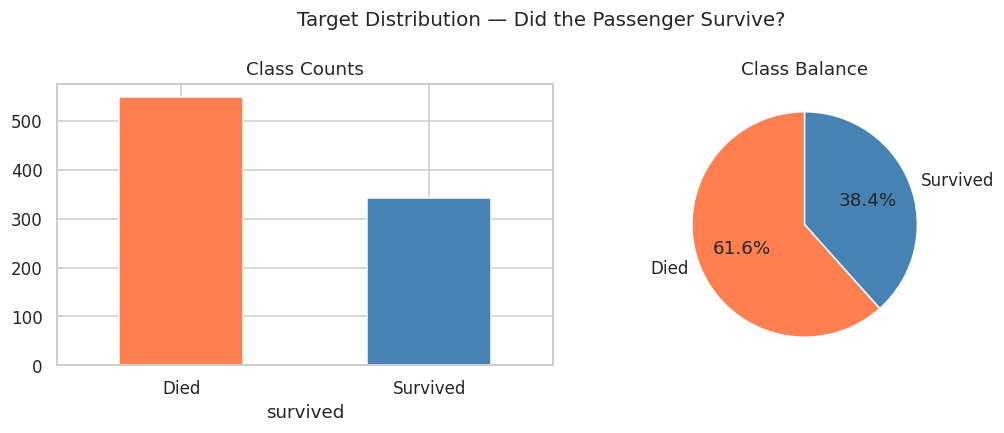

Survival rate: 38.4%


In [4]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc = df_raw['survived'].value_counts()
vc.plot.bar(ax=axes[0], color=['coral', 'steelblue'], edgecolor='white')
axes[0].set_title('Class Counts')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

df_raw['survived'].value_counts(normalize=True).plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['coral', 'steelblue'],
    labels=['Died', 'Survived'], startangle=90
)
axes[1].set_ylabel('')
axes[1].set_title('Class Balance')
plt.suptitle('Target Distribution — Did the Passenger Survive?', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Survival rate: {df_raw["survived"].mean():.1%}')

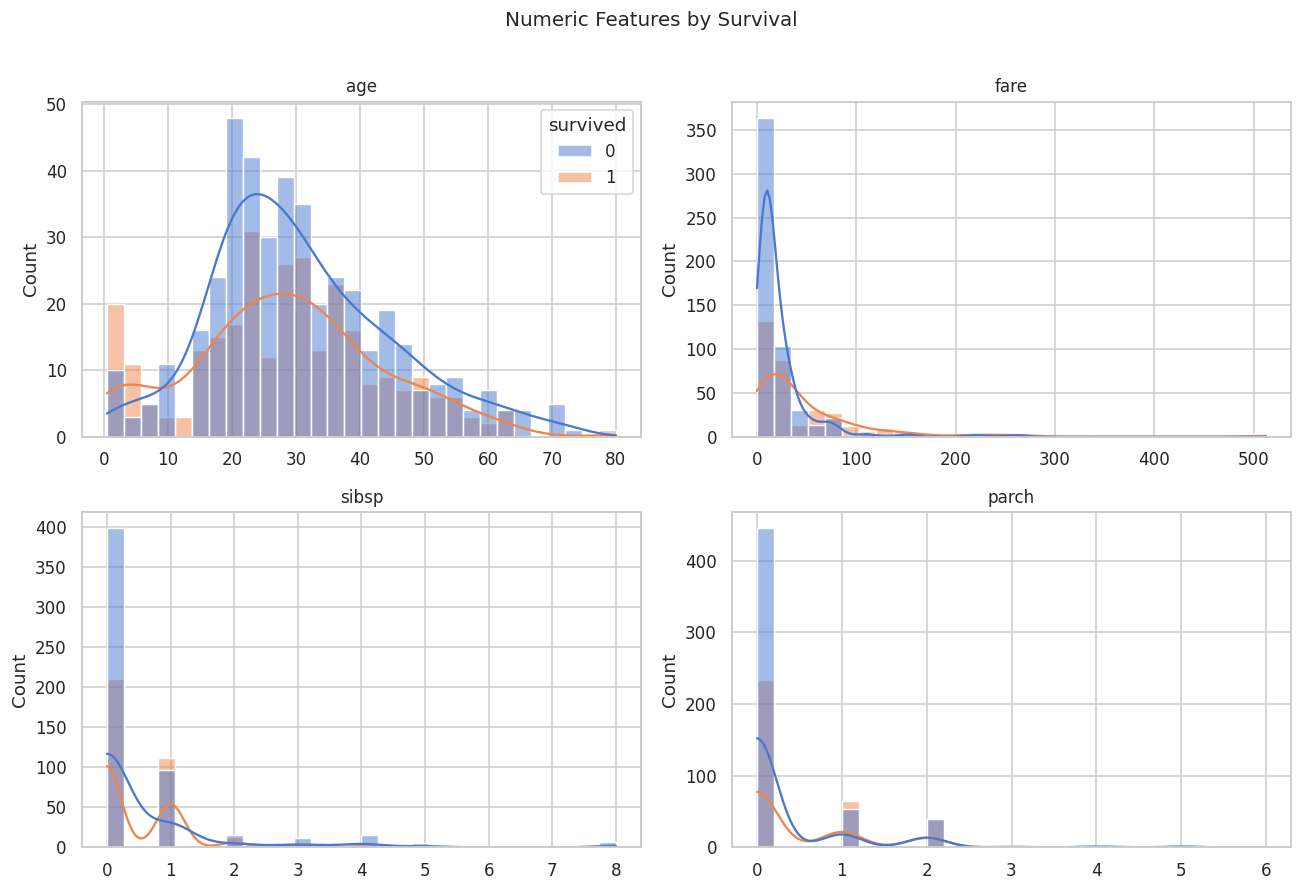

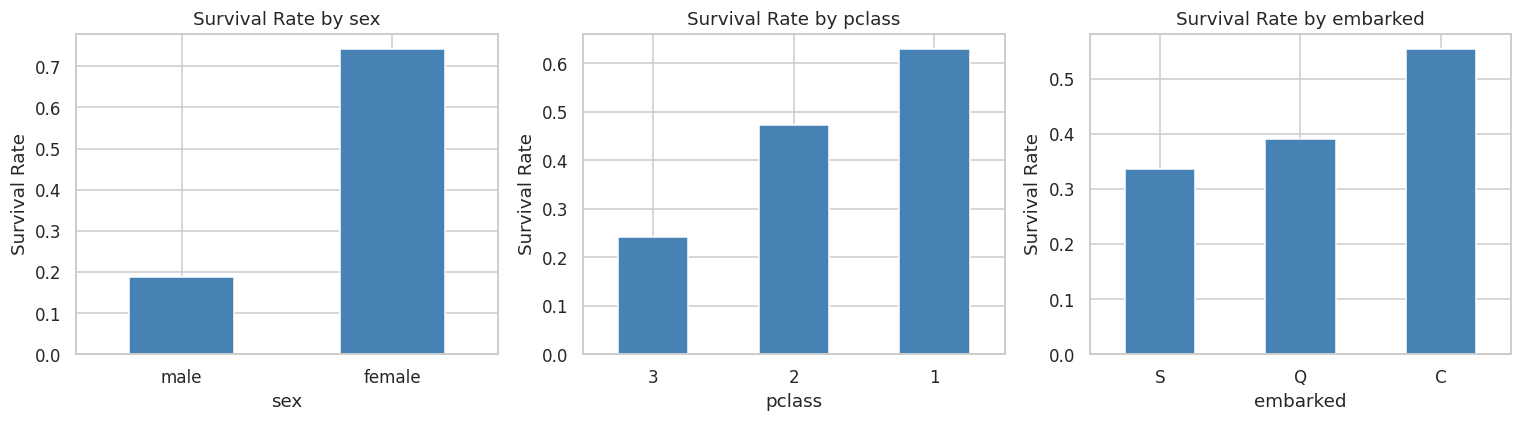

In [5]:
# Numeric feature distributions by survival
num_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(num_cols, axes.flatten()):
    sns.histplot(data=df_raw, x=col, hue='survived', kde=True, ax=ax,
                 bins=30, legend=(col == 'age'))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Numeric Features by Survival', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Survival rate by categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for col, ax in zip(['sex', 'pclass', 'embarked'], axes):
    if col in df_raw.columns:
        df_raw.groupby(col)['survived'].mean().sort_values().plot.bar(
            ax=ax, color='steelblue', edgecolor='white'
        )
        ax.set_title(f'Survival Rate by {col}')
        ax.set_ylabel('Survival Rate')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 🔧 3. Preprocessing & Feature Engineering

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Feature engineering ──────────────────────────────────────────────────
df = df_raw.copy()

# Drop columns with too many unique values or that leak the target
DROP_COLS = [c for c in ['name', 'ticket', 'cabin', 'boat', 'body',
                          'home.dest', 'who', 'deck', 'embark_town',
                          'alive', 'alone'] if c in df.columns]
df = df.drop(columns=DROP_COLS)

# Derived features
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone']    = (df['family_size'] == 1).astype(int)
df['fare_log']    = np.log1p(df['fare'])

# Title extraction from 'name' (if present in original)
if 'name' in df_raw.columns:
    df['title'] = df_raw['name'].str.extract(r',\s*([^\.]+)\.').iloc[:, 0].str.strip()
    df['title'] = df['title'].replace({
        'Mlle':'Miss','Ms':'Miss','Mme':'Mrs',
        'Lady':'Royalty','Countess':'Royalty','Jonkheer':'Royalty',
        'Don':'Sir','Sir':'Sir','Capt':'Officer',
        'Col':'Officer','Major':'Officer','Dr':'Officer','Rev':'Officer'
    })

TARGET = 'survived'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Survival rate — Train: {y_train.mean():.2%}  Test: {y_test.mean():.2%}')

Train: (712, 12)  Test: (179, 12)
Survival rate — Train: 38.34%  Test: 38.55%


In [7]:
# ── Build ColumnTransformer ───────────────────────────────────────────────
NUMERIC_COLS  = [c for c in ['age', 'fare', 'fare_log', 'sibsp', 'parch',
                              'family_size', 'is_alone', 'pclass'] if c in X_train.columns]
NOMINAL_COLS  = [c for c in ['sex', 'embarked', 'title'] if c in X_train.columns]

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

transformer = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_COLS),
    ('nom', nominal_pipe, NOMINAL_COLS),
], remainder='drop', verbose_feature_names_out=True)

X_train_t = transformer.fit_transform(X_train)
X_test_t  = transformer.transform(X_test)
feat_names = list(transformer.get_feature_names_out())

joblib.dump(transformer, 'models/transformer.pkl')
print(f'✅ Features after engineering: {X_train_t.shape[1]}')
print(f'   Numeric : {NUMERIC_COLS}')
print(f'   Nominal : {NOMINAL_COLS}')

✅ Features after engineering: 13
   Numeric : ['age', 'fare', 'fare_log', 'sibsp', 'parch', 'family_size', 'is_alone', 'pclass']
   Nominal : ['sex', 'embarked']


## 🏋️ 4. Train Models + MLflow Tracking

In [8]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score,
                              precision_score, recall_score)
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

mlflow.set_tracking_uri('mlruns')
exp = mlflow.set_experiment('titanic-survival')

def metrics(model, X, y):
    yp    = model.predict(X)
    yprob = model.predict_proba(X)[:, 1]
    return {
        'roc_auc'  : round(roc_auc_score(y, yprob), 4),
        'f1'       : round(f1_score(y, yp), 4),
        'precision': round(precision_score(y, yp), 4),
        'recall'   : round(recall_score(y, yp), 4),
    }

results = []

# ── Logistic Regression ──────────────────────────────────────────────────
with mlflow.start_run(run_name='logistic_regression'):
    params = dict(C=1.0, max_iter=500, class_weight='balanced', random_state=42)
    lr = LogisticRegression(**params).fit(X_train_t, y_train)
    m  = metrics(lr, X_test_t, y_test)
    mlflow.log_params(params)
    mlflow.log_metrics(m)
    mlflow.sklearn.log_model(lr, 'model',
        signature=infer_signature(X_train_t, lr.predict(X_train_t)))
    results.append(('Logistic Regression', lr, m))
    print(f'LR   | AUC={m["roc_auc"]}  F1={m["f1"]}')

# ── Random Forest ────────────────────────────────────────────────────────
with mlflow.start_run(run_name='random_forest'):
    params = dict(n_estimators=300, max_depth=8,
                  class_weight='balanced', random_state=42, n_jobs=-1)
    rf = RandomForestClassifier(**params).fit(X_train_t, y_train)
    m  = metrics(rf, X_test_t, y_test)
    mlflow.log_params(params)
    mlflow.log_metrics(m)
    mlflow.sklearn.log_model(rf, 'model',
        signature=infer_signature(X_train_t, rf.predict(X_train_t)))
    results.append(('Random Forest', rf, m))
    print(f'RF   | AUC={m["roc_auc"]}  F1={m["f1"]}')

# ── XGBoost + Optuna ─────────────────────────────────────────────────────
def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 400),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, eval_metric='auc',
    )
    m = xgb.XGBClassifier(**p).fit(X_train_t, y_train, verbose=False)
    return roc_auc_score(y_test, m.predict_proba(X_test_t)[:, 1])

print('Tuning XGBoost (20 trials)...')
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

best_p = study.best_params
best_p.update(dict(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric='auc'
))

with mlflow.start_run(run_name='xgboost_optuna'):
    xgb_model = xgb.XGBClassifier(**best_p).fit(X_train_t, y_train, verbose=False)
    m  = metrics(xgb_model, X_test_t, y_test)
    mlflow.log_params(best_p)
    mlflow.log_metrics(m)
    mlflow.sklearn.log_model(xgb_model, 'model',
        signature=infer_signature(X_train_t, xgb_model.predict(X_train_t)))
    results.append(('XGBoost', xgb_model, m))
    print(f'XGB  | AUC={m["roc_auc"]}  F1={m["f1"]}')

2026/04/21 03:26:30 INFO mlflow.tracking.fluent: Experiment with name 'titanic-survival' does not exist. Creating a new experiment.
2026/04/21 03:26:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 03:26:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR   | AUC=0.8435  F1=0.7586


2026/04/21 03:26:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 03:26:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF   | AUC=0.8408  F1=0.75
Tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

2026/04/21 03:26:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 03:26:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB  | AUC=0.8408  F1=0.7591


In [9]:
# Model comparison table
summary = pd.DataFrame(
    [(n, v['roc_auc'], v['f1'], v['precision'], v['recall'])
     for n, _, v in results],
    columns=['Model', 'ROC-AUC', 'F1', 'Precision', 'Recall']
).set_index('Model').sort_values('ROC-AUC', ascending=False)

summary.style.highlight_max(axis=0, color='#d4f1c4').format('{:.4f}')

,ROC-AUC,F1,Precision,Recall
Model,,,,
Logistic Regression,0.8435,0.7586,0.7237,0.7971
Random Forest,0.8408,0.7500,0.7612,0.7391
XGBoost,0.8408,0.7591,0.7647,0.7536


## 📊 5. Evaluation Plots

🏆 Best model: Logistic Regression


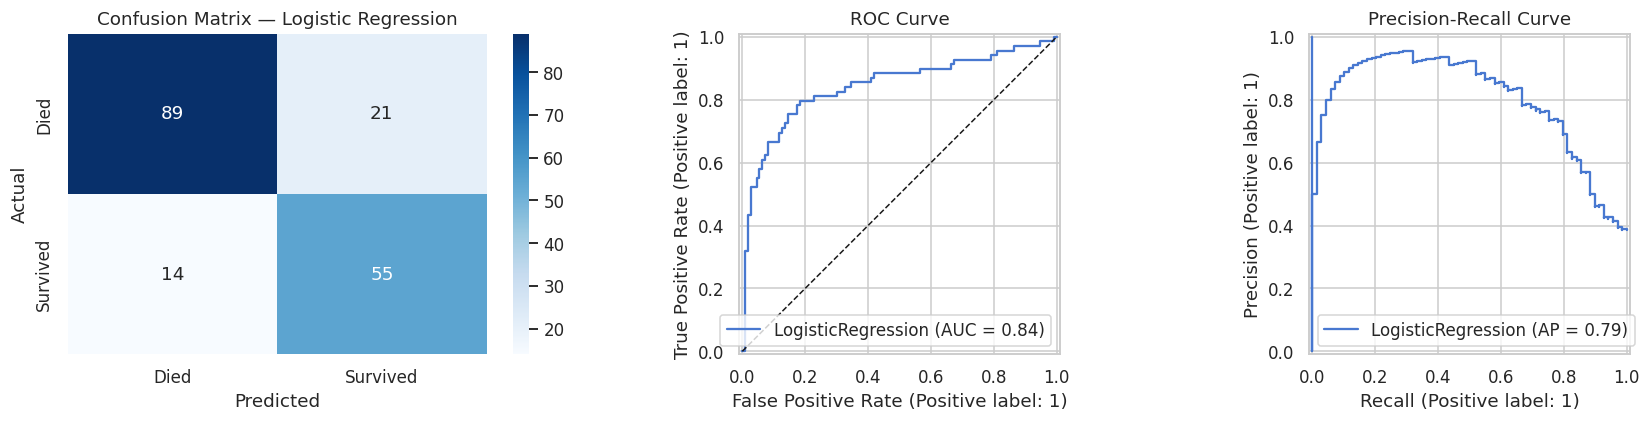

In [10]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay

# Pick best model
best_name, best_model, _ = max(results, key=lambda x: x[2]['roc_auc'])
joblib.dump(best_model, 'models/best_model.pkl')
print(f'🏆 Best model: {best_name}')

cm = confusion_matrix(y_test, best_model.predict(X_test_t))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_estimator(best_model, X_test_t, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve')

PrecisionRecallDisplay.from_estimator(best_model, X_test_t, y_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('reports/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 6. SHAP Explainability

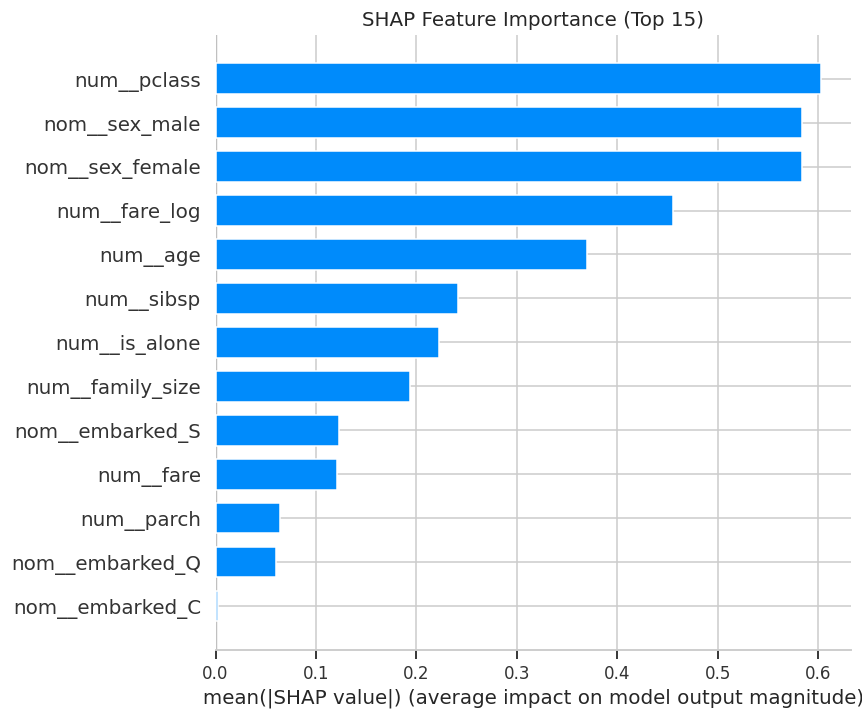

In [12]:
import shap

n_sample = min(500, X_test_t.shape[0])
X_sample = pd.DataFrame(X_test_t, columns=feat_names).sample(n_sample, random_state=42)

# Use LinearExplainer for LogisticRegression models
explainer   = shap.LinearExplainer(best_model, X_train_t)
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Feature importance bar
plt.figure(figsize=(8, 6))
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance (Top 15)', fontsize=13)
plt.tight_layout()
plt.savefig('reports/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

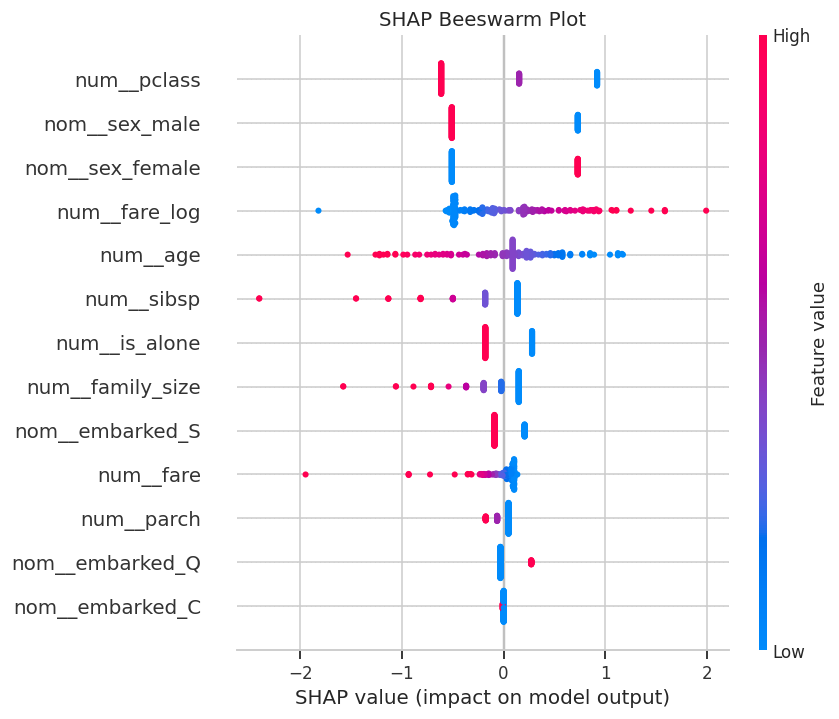

In [13]:
# SHAP beeswarm — shows direction of impact
plt.figure(figsize=(8, 8))
shap.summary_plot(sv, X_sample, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot', fontsize=13)
plt.tight_layout()
plt.savefig('reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌐 7. FastAPI Server + Test Predictions

In [14]:
%%writefile api_app.py
import joblib, numpy as np, pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app         = FastAPI(title='Titanic Survival Predictor')
model       = joblib.load('models/best_model.pkl')
transformer = joblib.load('models/transformer.pkl')

class PassengerInput(BaseModel):
    pclass:      int            # 1, 2, or 3
    sex:         str            # male / female
    age:         Optional[float] = None
    sibsp:       int   = 0
    parch:       int   = 0
    fare:        float = 32.0
    embarked:    Optional[str]  = 'S'   # S / C / Q
    title:       Optional[str]  = None  # Mr / Mrs / Miss / Master / Officer / Royalty / Sir

@app.get('/')
def root():
    return {'status': 'ok', 'model': 'titanic-survival'}

@app.post('/predict')
def predict(data: PassengerInput):
    age       = data.age if data.age is not None else 29.0
    fare      = data.fare
    family_sz = data.sibsp + data.parch + 1
    is_alone  = int(family_sz == 1)
    fare_log  = float(np.log1p(fare))
    title     = data.title or ('Mr' if data.sex == 'male' else 'Mrs')

    row = pd.DataFrame([{
        'age':         age,
        'fare':        fare,
        'fare_log':    fare_log,
        'sibsp':       data.sibsp,
        'parch':       data.parch,
        'family_size': family_sz,
        'is_alone':    is_alone,
        'pclass':      data.pclass,
        'sex':         data.sex,
        'embarked':    data.embarked,
        'title':       title,
    }])

    X    = transformer.transform(row)
    prob = float(model.predict_proba(X)[0, 1])
    return {
        'prediction':  'survived' if prob >= 0.5 else 'died',
        'probability': round(prob, 4)
    }

Writing api_app.py


In [15]:
import nest_asyncio, uvicorn, threading
nest_asyncio.apply()

def run():
    uvicorn.run('api_app:app', host='0.0.0.0', port=8000, log_level='error')

threading.Thread(target=run, daemon=True).start()
print('✅ API running at http://localhost:8000')

✅ API running at http://localhost:8000


In [16]:
import requests, time
time.sleep(2)

# Rose — 1st class, female, young
rose = {'pclass': 1, 'sex': 'female', 'age': 17, 'sibsp': 1,
        'parch': 1, 'fare': 263.0, 'embarked': 'S', 'title': 'Miss'}

# Jack — 3rd class, male, young adult
jack = {'pclass': 3, 'sex': 'male', 'age': 20, 'sibsp': 0,
        'parch': 0, 'fare': 7.25, 'embarked': 'S', 'title': 'Mr'}

for name, payload in [('Rose', rose), ('Jack', jack)]:
    resp = requests.post('http://localhost:8000/predict', json=payload)
    r    = resp.json()
    print(f'{name:4s} → {r["prediction"]:10s} (prob={r["probability"]})')

Rose → survived   (prob=0.9651)
Jack → died       (prob=0.1721)
